In [4]:
import base
import numpy as np
import matplotlib.pyplot as plt

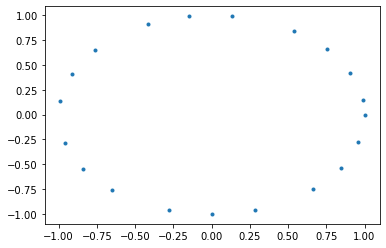

In [18]:
t = np.arange(20)
x = np.cos(np.arange(20))
y = np.sin(np.arange(20))
plt.plot(x,y,marker='.' ,linestyle='')

In [16]:
D = np.zeros((20,20))
for i in range(len(x)):
    for j in range(len(y)):
        D[i,j] = np.sqrt((x[i]-x[j])**2+ (y[i]-y[j])**2)     

In [52]:
s = base.traveling_MC_constDist(t,D,10000)[0]
s_hist = base.traveling_MC_constDist_history(t,D,10000)[1]

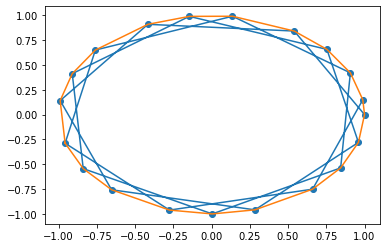

In [55]:
x_sort = x[s]
y_sort = y[s]
X = np.append(x_sort,x_sort[0])
Y = np.append(y_sort,y_sort[0])

plt.scatter(x,y)
plt.plot(x,y)
plt.plot(X,Y)

In [33]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [58]:
fig, ax = plt.subplots(figsize=(5,5))

def init():
    ax.clear()
    
def update(framenr):
    speed = 11 # 11 frames per animation 
    
   
    
    ax.clear() # clear the old plot
    

    ax.axes.xaxis.set_ticks([]) # removes x,y positions
    ax.axes.yaxis.set_ticks([])
    
    # Plots
    ind = np.int_(s_hist[framenr*speed])
    x_sort = x[ind]
    y_sort = y[ind]
    X = np.append(x_sort,x_sort[0])
    Y = np.append(y_sort,y_sort[0])
    ax.scatter(x, y,s = 4, label = "Points" , color = 'blue') 
    ax.plot(X, Y,  label = "Path", color = 'red')
    ax.legend(loc = 'upper left')

anim = FuncAnimation(
    fig, 
    update,
    frames=np.arange(0,250),
    init_func=init,
    blit=False)

plt.close(fig)

# Show Animation directly in th Notebook

HTML(anim.to_jshtml())